## **1. Mount google drive**
---

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


## **2. Import the necessary libraries**
---

In [1]:
import matplotlib
import sklearn
import numpy as np
import pandas as pd
import sklearn.metrics as metrics
import matplotlib.pyplot as plt
import tensorflow as tf
import os


from tensorflow.keras.callbacks import ModelCheckpoint,CSVLogger
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.utils import plot_model


print("Versions of key libraries")
print("---")
print("tensorflow: ", tf.__version__)
print("numpy:      ", np.__version__)
print("matplotlib: ", matplotlib.__version__)
print("sklearn:    ", sklearn.__version__)

Versions of key libraries
---
tensorflow:  2.18.0
numpy:       2.3.3
matplotlib:  3.10.6
sklearn:     1.7.2


## **3.Create a function to plot the japanese character correctly**
---

In [2]:
def grayplt(img,title=''):
    plt.axis('off')
    if np.size(img.shape) == 3:
        plt.imshow(img[:,:,0],cmap='gray',vmin=0,vmax=1)
    else:
        plt.imshow(img,cmap='gray',vmin=0,vmax=1)
    plt.title(title, fontproperties=prop)
    plt.show()

print(grayplt)

<function grayplt at 0x2b20faf0dee0>


## **4. Setup matplotlib**
---

In [3]:
                                          # Setting up the font manager, so that
                                          # it can show japanese characters correctly
from matplotlib import font_manager as fm
fpath       = os.path.join(os.getcwd(), "ipam.ttf")
prop        = fm.FontProperties(fname=fpath)

plt.style.use('ggplot')
plt.rcParams['ytick.right']     = True
plt.rcParams['ytick.labelright']= True
plt.rcParams['ytick.left']      = False
plt.rcParams['ytick.labelleft'] = False
plt.rcParams['figure.figsize']  = [7,7]   # Set the figure size to be 7 inch for (width,height)

print("Matplotlib setup completes.")

Matplotlib setup completes.


## **5. Prepare data for training and testing**
---
* Step 1: Load the dataset
* Step 2: Check the shape and type of the data, plot a sample for observation
* Step 3: Convert the data into float32 and rescale the values from the range of 0\~255 into 0\~1
* Step 4: Retrieve the row size and the column size of each image
* Step 5: Reshape training and testing data to be in the form of `[samples,rows,columns,channel]`. This is required by Keras framework
* Step 6: Perform one-hot enconding on the labels
* Step 7: Retrieve the number of classes in this problem

The shape of trDat is (60000, 28, 28) and the type of trDat is uint8
The shape of tsDat is (10000, 28, 28) and the type of tsDat is uint8

The shape of trLbl is (60000,) and the type of trLbl is uint8
The shape of tsLbl is (10000,) and the type of tsLbl is uint8



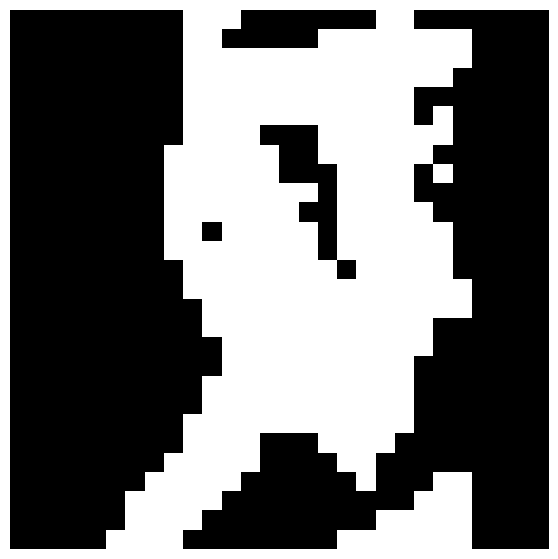

In [4]:
                                                                                # Step 1
# trDat       = np.load('/content/gdrive/My Drive/iss/psupr/data/kmnist-train-imgs.npz')['arr_0']
# trLbl       = np.load('/content/gdrive/My Drive/iss/psupr/data/kmnist-train-labels.npz')['arr_0']
# tsDat       = np.load('/content/gdrive/My Drive/iss/psupr/data/kmnist-test-imgs.npz')['arr_0']
# tsLbl       = np.load('/content/gdrive/My Drive/iss/psupr/data/kmnist-test-labels.npz')['arr_0']
trDat       = np.load('kmnist-train-imgs.npz')['arr_0']
trLbl       = np.load('kmnist-train-labels.npz')['arr_0']
tsDat       = np.load('kmnist-test-imgs.npz')['arr_0']
tsLbl       = np.load('kmnist-test-labels.npz')['arr_0']

                                                                                # Step 2
print("The shape of trDat is", trDat.shape, "and the type of trDat is", trDat.dtype)
print("The shape of tsDat is", tsDat.shape, "and the type of tsDat is", tsDat.dtype)
print("")
print("The shape of trLbl is", trLbl.shape, "and the type of trLbl is", trLbl.dtype)
print("The shape of tsLbl is", tsLbl.shape, "and the type of tsLbl is", tsLbl.dtype)
print("")
grayplt(trDat[132]) #plot any random image from the training dataset

                                                                                # Step 3
trDat           = trDat.astype('float32')/255
tsDat           = tsDat.astype('float32')/255

                                                                                # Step 4
imgrows         = trDat.shape[1]
imgclms         = trDat.shape[2]

                                                                                # Step 5
trDat       = trDat.reshape(trDat.shape[0],
                            imgrows,
                            imgclms,
                            1)
tsDat       = tsDat.reshape(tsDat.shape[0],
                            imgrows,
                            imgclms,
                            1)

                                                                                # Step 6
trLbl           = to_categorical(trLbl)
tsLbl           = to_categorical(tsLbl)

num_classes     = tsLbl.shape[1]                                                # Step 7

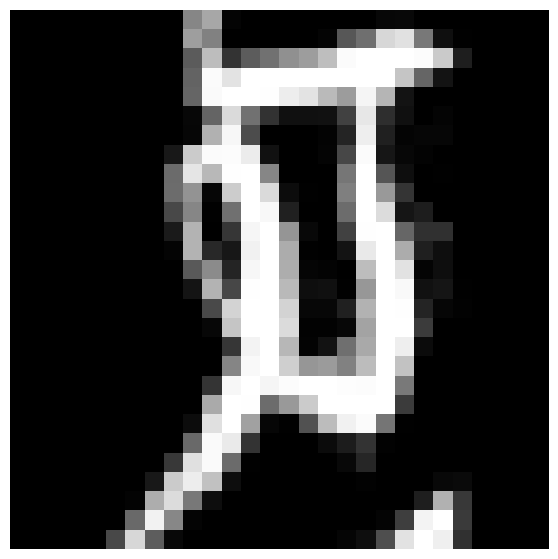

In [10]:
grayplt(trDat[132])

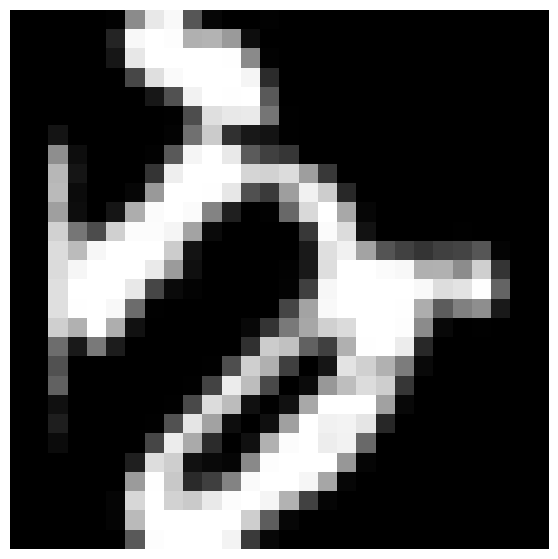

In [8]:
grayplt(trDat[1008])

## **6. Define deep learning model (to be completed)**
___
* Step 1: Set a name for the coming model (required for saving)
* Step 2: Define the convolutional neural network model (to be completed)
* Step 3: Create models for training and testing
* Step 4: Display the summary of the model of interest

**You may trial and error various structures (for input or number of channels or kernels sizes or pooling sizes) and see what happens to the performance**

In [20]:
modelname   = 'wks5_5'                                                          # Step 1
seed = 29
np.random.seed(seed)
                                                                                # Step 2
def createModel():
    model = Sequential()
    model.add(Conv2D(20, (5, 5), input_shape=(28, 28, 1), activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    # model.add(MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))
    # model.add(Dropout(0.2))
    model.add(Conv2D(40, (5, 5), activation='relu'))
    # model.add(Conv2D(40, (5, 5), strides=(2, 2), activation='relu', padding='same/valid'))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.2))
    model.add(Flatten())
    model.add(Dense(128, activation='relu'))

    model.add(Dense(num_classes, activation='softmax'))
    model.compile(loss='categorical_crossentropy', optimizer='adam',
metrics=['accuracy'])

    return model

                                                                                # Step 3
model       = createModel() # This is meant for training
modelGo     = createModel() # This is used for final testing

model.summary()                                                                 # Step 4

/hpctmp/e1554287/conda/envs/tf312/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 24, 24, 20)     │           520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 12, 20)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 8, 8, 40)       │        20,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 4, 4, 40)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4, 4, 40)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 640)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 103,898 (405.85 KB)

 Trainable params: 103,898 (405.85 KB)

 Non-trainable params: 0 (0.00 B)

## **7. Create the callbacks to be applied during training**
---
* Step 1: Create a callback to save the model from an epoch when validation accuracy is the highest
* Step 2: Create a callback to save the training loss, training accuracy, validation loss and validation accuracy of each epoch into a csv file
* Step 3: Put the two callbacks objects into a list

In [11]:
import sys
from pathlib import Path

In [17]:
Path().resolve()

PosixPath('/home/svu/e1554287/projects/ideal-ML-train/deep-learning')

In [ ]:
# Add project root in case we need to read from parent dir
ROOT_DIR = Path().resolve().parents[0]

In [24]:
                                                                                # Step 1
# folderpath      = '/content/gdrive/My Drive/iss/psupr/colab/'
folderpath      = str(Path()) +"/" #in case code is at same location as data
filepath        = folderpath + modelname + ".keras"
checkpoint      = ModelCheckpoint(filepath,
                                  monitor='val_accuracy',
                                  verbose=0,
                                  save_best_only=True,
                                  mode='max')

csv_logger      = CSVLogger(folderpath+modelname +'.csv')                       # Step 2
callbacks_list  = [checkpoint,csv_logger]                                       # Step 3

print("Callbacks created:")
print(callbacks_list[0])
print(callbacks_list[1])
print('')
print("Path to model:", filepath)
print("Path to log:  ", folderpath+modelname+'.csv')

Callbacks created:

Path to model: ./wks5_5.keras
Path to log:   ./wks5_5.csv


## **8. Train the deep learning model**
___

In [25]:
model.fit(trDat,                            # Training data
          trLbl,                            # Training label
          validation_data=(tsDat, tsLbl),   # Validation data and label
          epochs=10,                       # The amount of epochs to be trained
          batch_size=128,   #expected batches=60000/128 = 469
          shuffle=True,                     # To shuffle the training data
          callbacks=callbacks_list)         # Callbacks to execute the checkpoints

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - accuracy: 0.8523 - loss: 0.4725 - val_accuracy: 0.8705 - val_loss: 0.4272
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.9527 - loss: 0.1557 - val_accuracy: 0.9138 - val_loss: 0.2970
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.9683 - loss: 0.1054 - val_accuracy: 0.9183 - val_loss: 0.2798
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.9762 - loss: 0.0774 - val_accuracy: 0.9396 - val_loss: 0.2146
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.9813 - loss: 0.0623 - val_accuracy: 0.9478 - val_loss: 0.1949
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.9842 - loss: 0.0506 - val_accuracy: 0.9483 - val_loss: 0.1931
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.9869 - loss: 0.0413 - val_accuracy: 0.9526 - val_loss: 0.1883
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.9888 - loss: 0.0359 - val_acc

###### explanation
| Term | Meaning |
| :------ | ----: |
| 469/469 | Keras has divided your training data into 469 mini-batches, and it is now showing progress: “batch # 469 out of 469 total” — i.e., it just completed the epoch. |
| 9s | total wall time for this epoch. |
| 18 ms/step | average time per batch (i.e., 18 ms per mini-batch of size 128). |
| accuracy / loss | metrics on training set for this epoch. |
| val_accuracy / val_loss | metrics on validation set (computed once per epoch). |

In [28]:
# ===== CONTINUE TRAINING =============
modelfurther = tf.keras.models.load_model("./wks5_5.keras")

# Optional sanity check: print model summary to confirm 103,898 parameters
modelfurther.summary()

# === Continue training for additional epochs ===
modelfurther.fit(
    trDat, trLbl,
    validation_data=(tsDat, tsLbl),
    epochs=20,            # continue training up to 20 (starts at 11 internally)
    batch_size=128,
    shuffle=True,
    verbose=2, verbose=2,
    callbacks=callbacks_list  # reuse your CSV logger + checkpoint
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 24, 24, 20)     │           520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 12, 20)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 8, 8, 40)       │        20,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 4, 4, 40)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4, 4, 40)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 640)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 311,696 (1.19 MB)

 Trainable params: 103,898 (405.85 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 207,798 (811.71 KB)

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.9935 - loss: 0.0185 - val_accuracy: 0.9591 - val_loss: 0.1734
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.9951 - loss: 0.0150 - val_accuracy: 0.9589 - val_loss: 0.1986
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.9948 - loss: 0.0157 - val_accuracy: 0.9599 - val_loss: 0.1836
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.9954 - loss: 0.0142 - val_accuracy: 0.9617 - val_loss: 0.1815
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.9958 - loss: 0.0124 - val_accuracy: 0.9638 - val_loss: 0.1784
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.9961 - loss: 0.0117 - val_accuracy: 0.9600 - val_loss: 0.2128
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.9961 - loss: 0.0119 - val_accuracy: 0.9604 - val_loss: 0.2030
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.9959 - loss: 0.0117 - val_accu

## **9. Validate the deep learning model**
---
* Step 1: Load the trained weights and compile the model
* Step 2: Make prediction


In [29]:
                                                                                # Step 1
modelGo.load_weights(filepath)
modelGo.compile(loss='categorical_crossentropy',
                optimizer='adam',
                metrics=['accuracy'])

predicts    = modelGo.predict(tsDat)                                            # Step 2
print("Prediction completes.")

 59/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

/hpctmp/e1554287/conda/envs/tf312/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Prediction completes.


## **10. Report classification metrics**
---
* Step 1: Setup the label
* Step 2: Convert label from one-hot to integer
* Step 3: Calculate the accuracy score
* Step 4: Generate classification report

In [30]:
                                                                                # Step 1
labelname   = ['お O','き Ki','す Su','つ Tsu','な Na','は Ha','ま Ma','や Ya','れ Re','を Wo']
                                                                                # Step 2
predout     = np.argmax(predicts,axis=1)
testout     = np.argmax(tsLbl,axis=1)

testScores  = metrics.accuracy_score(testout,predout)                           # Step 3

                                                                                # Step 4
print("Best accuracy (on testing dataset): %.2f%%" % (testScores*100))
print(metrics.classification_report(testout,
                                    predout,
                                    target_names=labelname,
                                    digits=4))

Best accuracy (on testing dataset): 96.62%
              precision    recall  f1-score   support

         お O     0.9660    0.9660    0.9660      1000
        き Ki     0.9657    0.9570    0.9613      1000
        す Su     0.9609    0.9350    0.9478      1000
       つ Tsu     0.9788    0.9680    0.9734      1000
        な Na     0.9522    0.9570    0.9546      1000
        は Ha     0.9508    0.9660    0.9583      1000
        ま Ma     0.9616    0.9770    0.9692      1000
        や Ya     0.9720    0.9710    0.9715      1000
        れ Re     0.9743    0.9850    0.9796      1000
        を Wo     0.9800    0.9800    0.9800      1000

    accuracy                         0.9662     10000
   macro avg     0.9662    0.9662    0.9662     10000
weighted avg     0.9662    0.9662    0.9662     10000



## **11. Print confusion matrix**
---

In [31]:
confusion   = metrics.confusion_matrix(testout,predout)
print(confusion)

[[966   3   2   0  15   5   0   6   2   1]
 [  2 957   8   0   9   1  13   3   5   2]
 [ 11   4 935  10   8  13   6   5   4   4]
 [  0   1   3 968   2  16   7   1   2   0]
 [  6   3   1   5 957   7   2   8   4   7]
 [  1   5  12   1   3 966   8   1   1   2]
 [  0   7   6   3   4   2 977   1   0   0]
 [ 10   3   1   0   3   2   2 971   4   4]
 [  0   6   2   2   3   0   0   2 985   0]
 [  4   2   3   0   1   4   1   1   4 980]]


## **12. Plot curves on validation loss and accuracy**
---

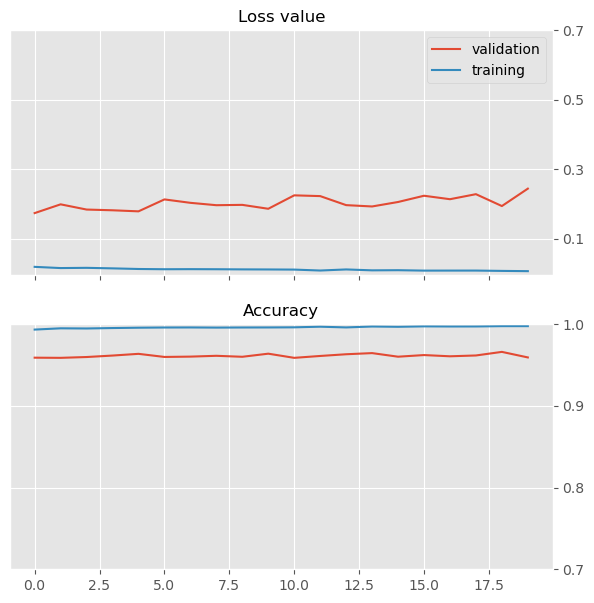

In [32]:
records     = pd.read_csv(folderpath+modelname +'.csv')
plt.figure()
plt.subplot(211)
plt.plot(records['val_loss'], label="validation")
plt.plot(records['loss'],label="training")
plt.yticks([0.10,0.30,0.50,0.70])
plt.title('Loss value',fontsize=12)

ax          = plt.gca()
ax.set_xticklabels([])

plt.subplot(212)
plt.plot(records['val_accuracy'],label="validation")
plt.plot(records['accuracy'],label="training")
plt.yticks([0.7,0.8,0.9,1.0])
plt.title('Accuracy',fontsize=12)
ax.legend()
plt.show()

## **13. Save the model plot**
---

In [33]:
plotpath  = folderpath+modelname+'_plot.png'
plot_model(model,
           to_file=plotpath,
           show_shapes=True,
           show_layer_names=False,
           rankdir='TB')

print("Path to plot:", plotpath)

Path to plot: ./wks5_5_plot.png
